### Scott 10k Symptoms

### Symptoms to be isolated:
1. MMSCORE (Memory)
2. CDGLOBAL (Cognition and Function)
3. NPI-Q (Behavioural symptoms)
    
Run Spearman's and Pearson's correlations between AD symptoms and beta coefficients:
<br>
   <br>(a) only 5-HT1a, H3 and mGluR5 since these had preserved relative feature importance between non-RFECV and RFECV desikan
   <br>(b) The top 7 beta coefficients from feature-selected SHAP (5-HT1A, H3, M1, mGluR5, MOR, CB1, a4b2)

Heatmap of SPEARMAN'S correlations - identify strongest absolute correlations

Regplot of diagnosis scores with beta coefficients - display along with PEARSON'S correlation

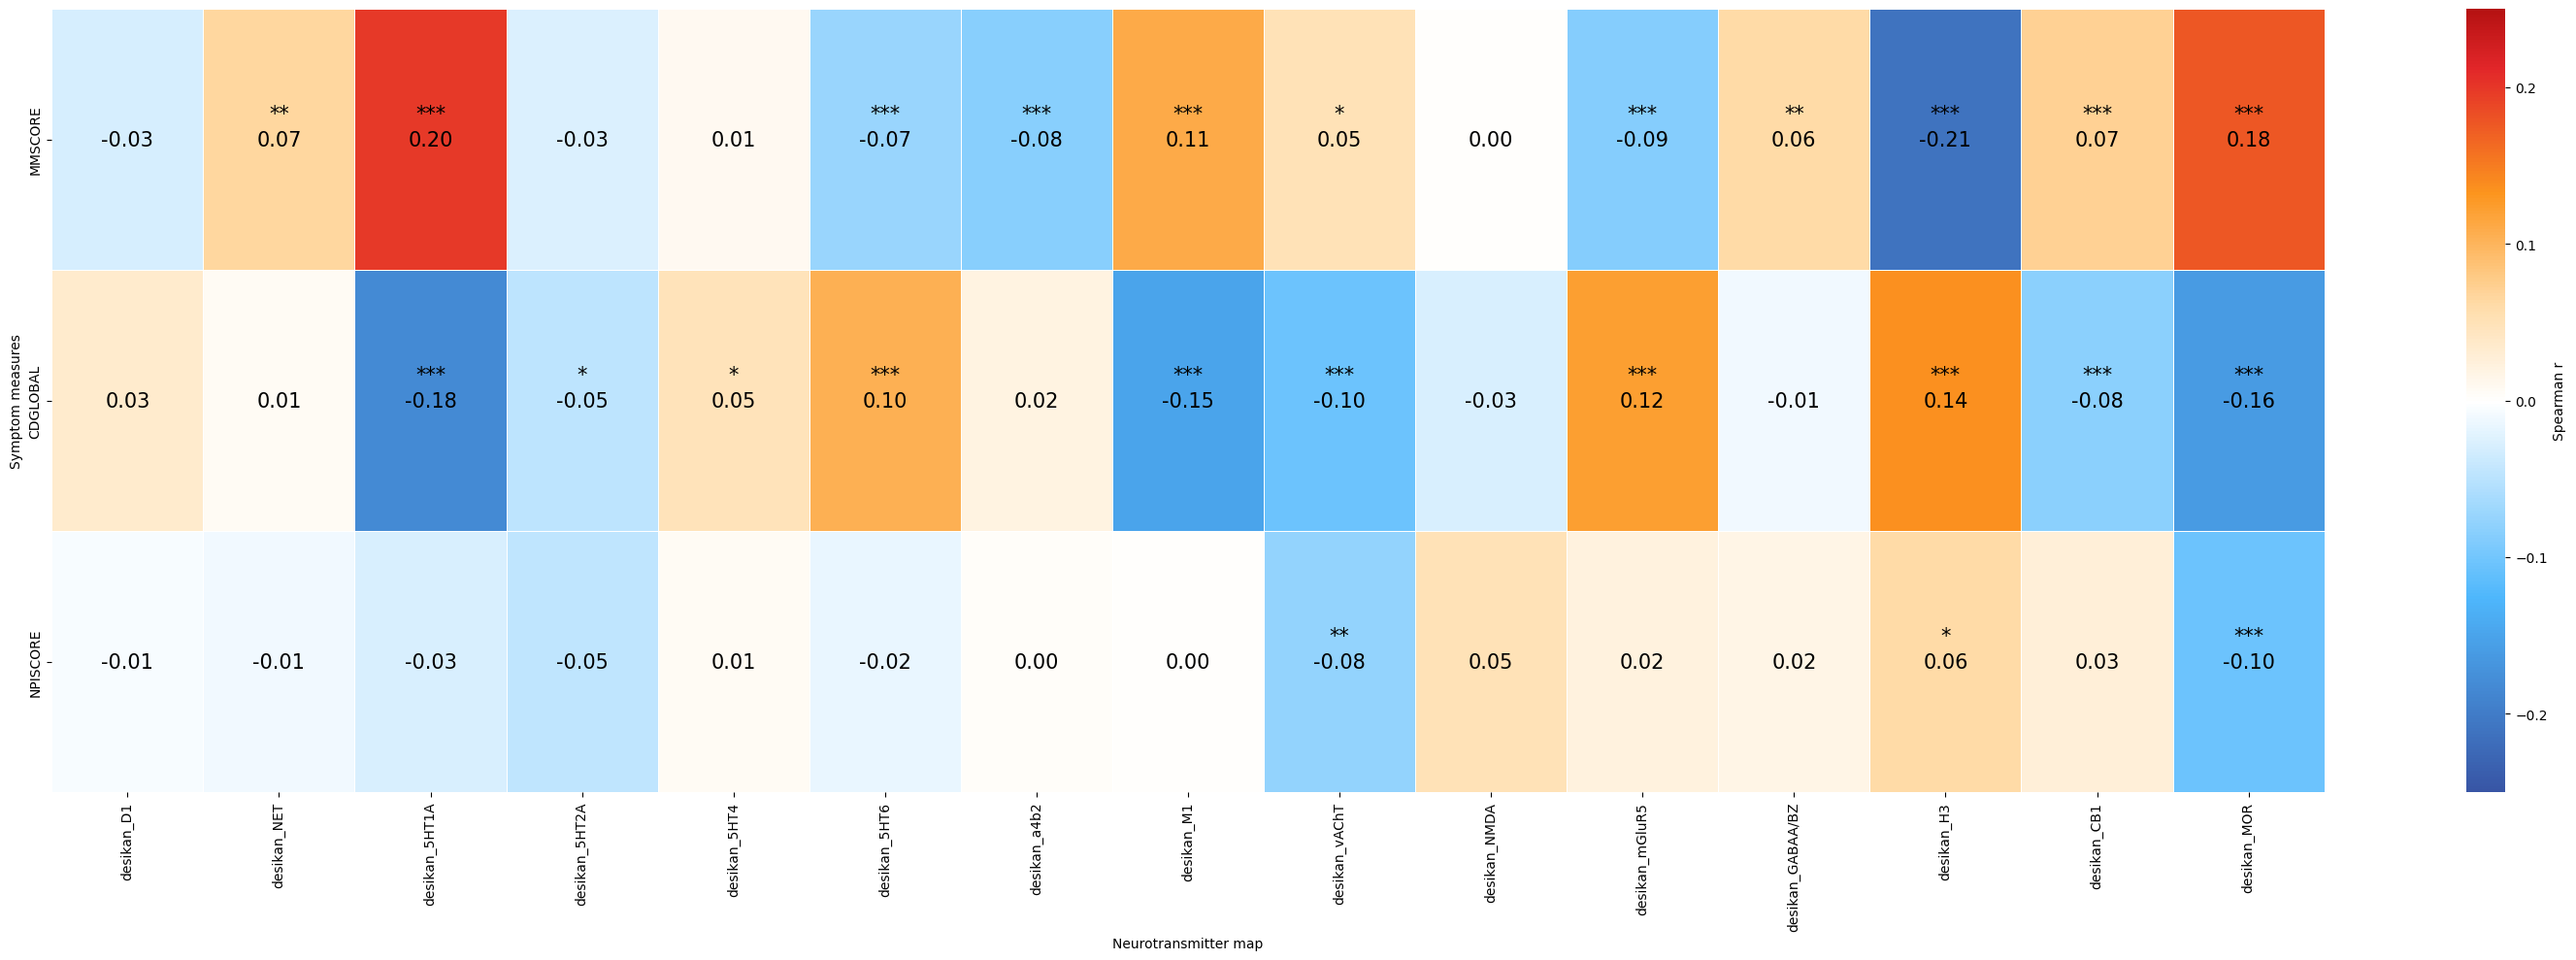

MMSCORE
Top feature: desikan_H3
Spearman r: -0.213
p-value (FDR): 7.371e-27
CDGLOBAL
Top feature: desikan_5HT1A
Spearman r: -0.182
p-value (FDR): 7.833e-20
NPISCORE
Top feature: desikan_MOR
Spearman r: -0.104
p-value (FDR): 1.672e-05


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats import multitest
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/heatmaps'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv',
    low_memory=False
)

coeff_cols = [
    'desikan_D1','desikan_NET','desikan_5HT1A','desikan_5HT2A','desikan_5HT4',
    'desikan_5HT6','desikan_a4b2','desikan_M1','desikan_vAChT','desikan_NMDA',
    'desikan_mGluR5','desikan_GABAA/BZ','desikan_H3','desikan_CB1','desikan_MOR'
]

symptom_cols = ['MMSCORE', 'CDGLOBAL', 'NPISCORE']

cmap = np.genfromtxt(
    'C:/Users/User/Downloads/deconstructalz.github.io/standards/colourmap.csv',
    delimiter=','
)
cmap_div = ListedColormap(cmap)

df_subset = df[['DIAGNOSIS'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS'] == 3]

r_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)
p_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        
        if len(tmp) > 1:
            r, p = spearmanr(tmp[coeff], tmp[symp])
        else:
            r, p = np.nan, np.nan

        r_values.loc[coeff, symp] = r
        p_values.loc[coeff, symp] = p

r_values = r_values.transpose()
p_values = p_values.transpose()

p_flat = p_values.values.flatten()
mask = ~np.isnan(p_flat)

p_corr = np.full_like(p_flat, np.nan)
p_corr[mask] = multitest.multipletests(p_flat[mask], method='fdr_bh')[1]

p_values = pd.DataFrame(
    p_corr.reshape(p_values.shape),
    index=p_values.index,
    columns=p_values.columns
)

plt.figure(figsize=(30, 10))

ax = sns.heatmap(
    r_values,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': "Spearman r"},
    annot_kws={'color': 'black', 'fontsize': 15, 'va': 'center'},
    linewidths=0.5,
    linecolor='white'
)

n_rows, n_cols = r_values.shape

for y in range(n_rows):
    for x in range(n_cols):
        r = r_values.iloc[y, x]
        p = p_values.iloc[y, x]

        if not np.isnan(r) and not np.isnan(p):
            stars = get_significance_stars(p)

            if stars:
                ax.text(
                    x + 0.5,     # center of cell (x)
                    y + 0.4,    # slightly above rho
                    stars,
                    ha='center',
                    va='center',
                    fontsize=15,
                    color='black'
                )

plt.xlabel('Neurotransmitter map')
plt.ylabel('Symptom measures')
plt.tight_layout()

plt.savefig(f"{outdir}/feature_select_spearman_heatmap_overlay_stars.png", dpi=300)

plt.show()

alpha = 0.05  # significance threshold (after FDR correction)

for symp in r_values.index:
    r_row = r_values.loc[symp]
    p_row = p_values.loc[symp]

    summary_df = pd.DataFrame({
        'rho': r_row,
        'abs_rho': r_row.abs(),
        'pval': p_row
    })

    # keep only significant results
    summary_df = summary_df[summary_df['pval'] <= alpha]

    if summary_df.empty:
        print(f"{symp}: no significant associations after correction")
        continue

    # sort by absolute rho
    summary_df = summary_df.sort_values(by='abs_rho', ascending=False)

    top = summary_df.iloc[0]
    
    print(symp)
    print(f"Top feature: {top.name}")
    print(f"Spearman r: {top['rho']:.3f}")
    print(f"p-value (FDR): {top['pval']:.3e}")

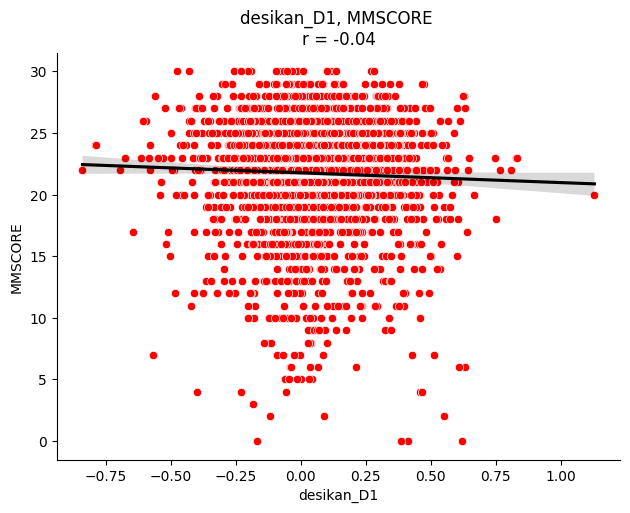

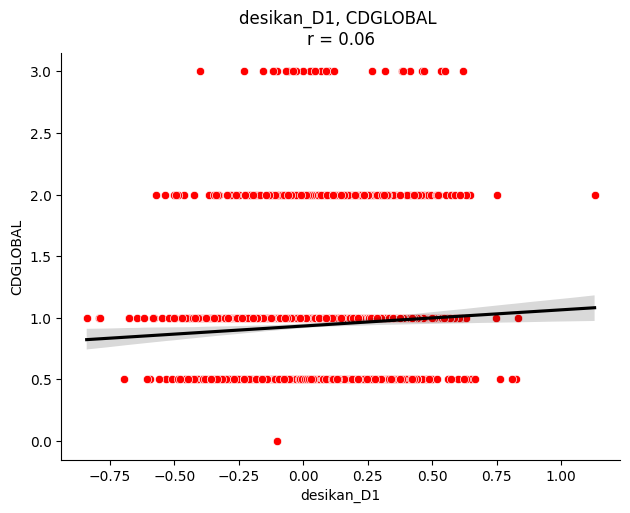

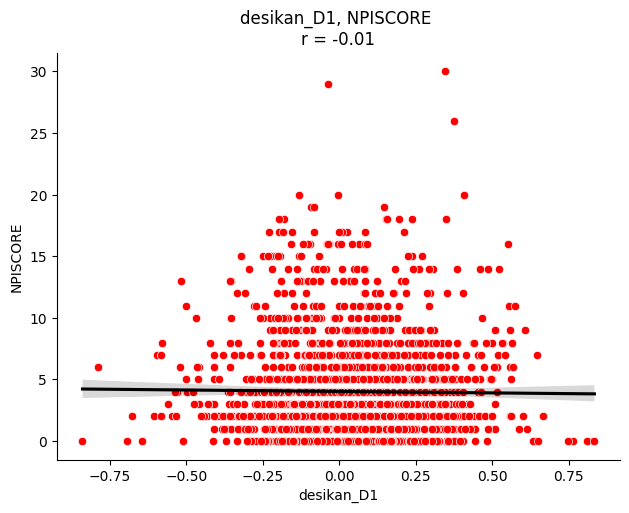

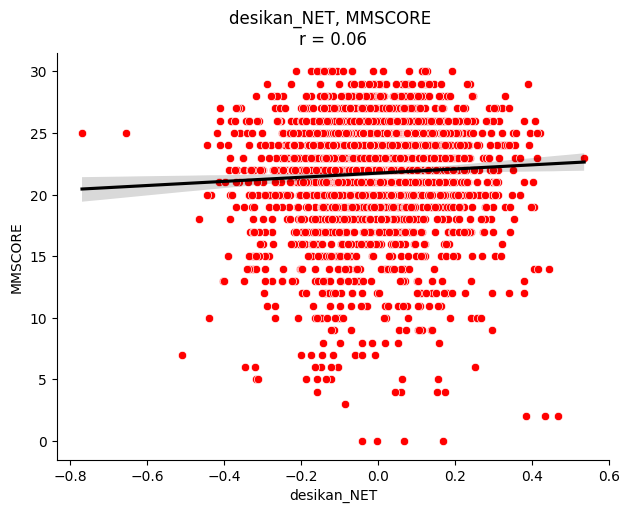

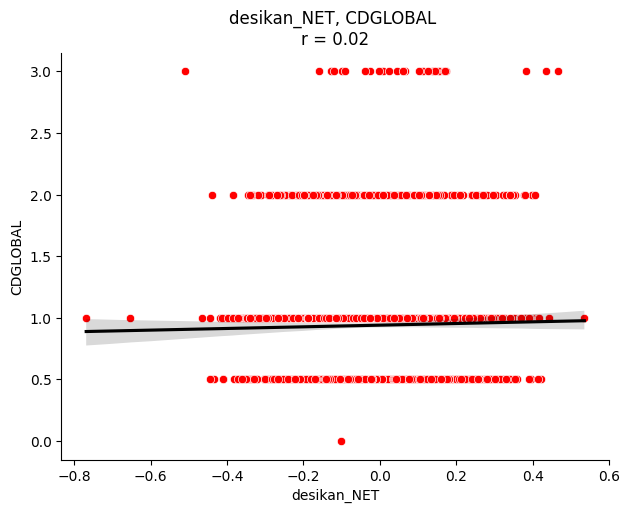

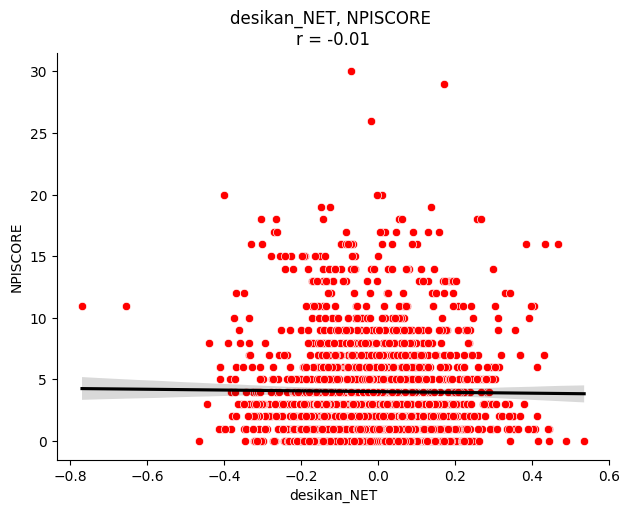

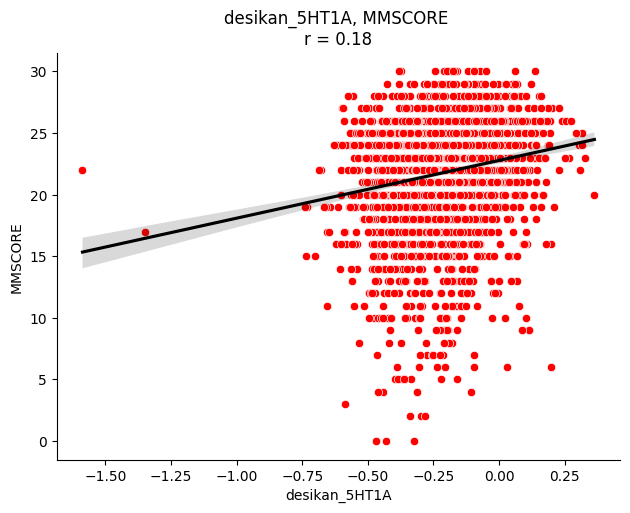

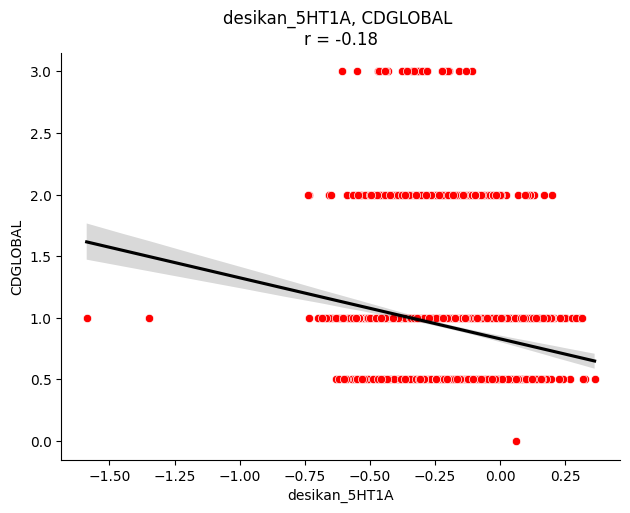

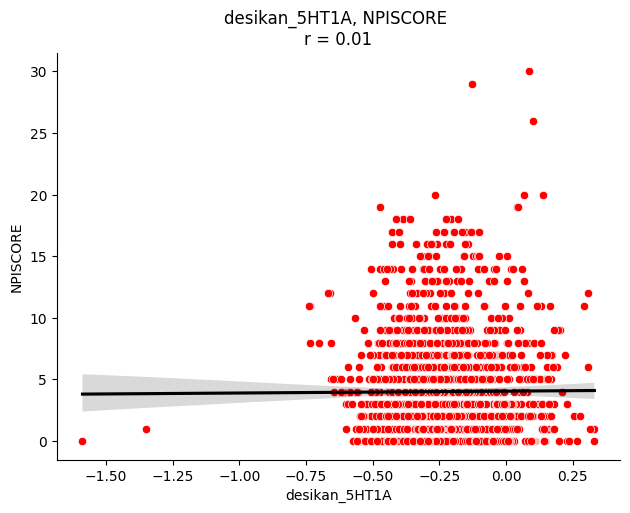

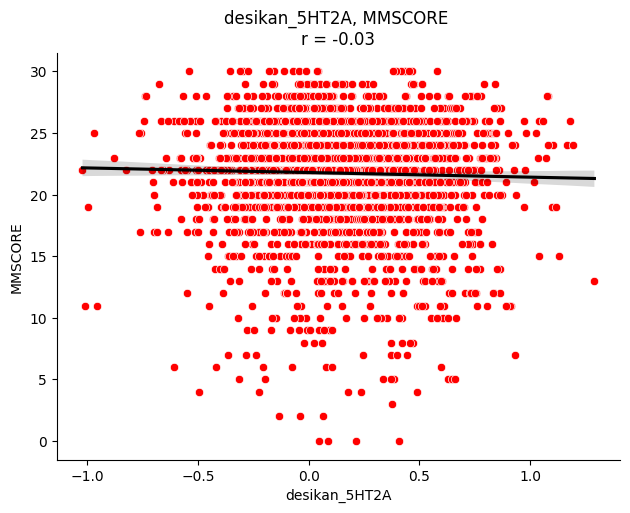

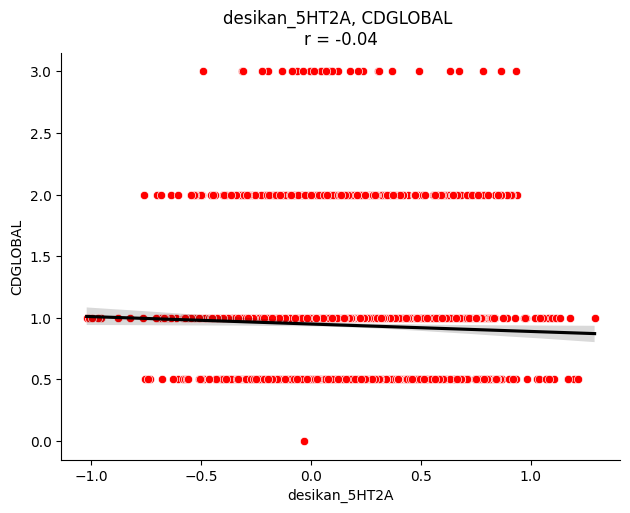

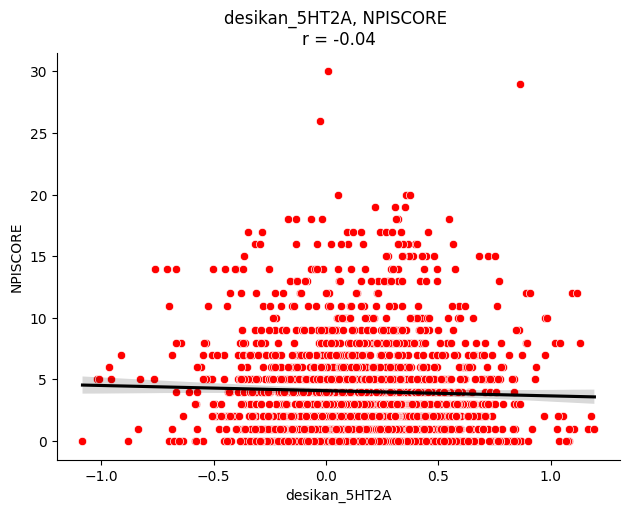

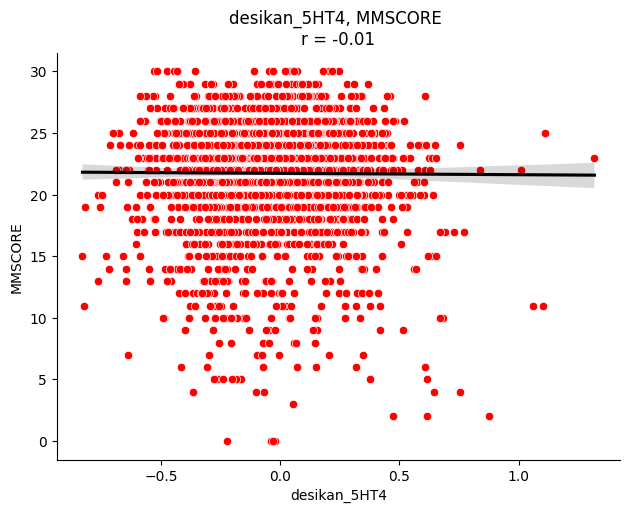

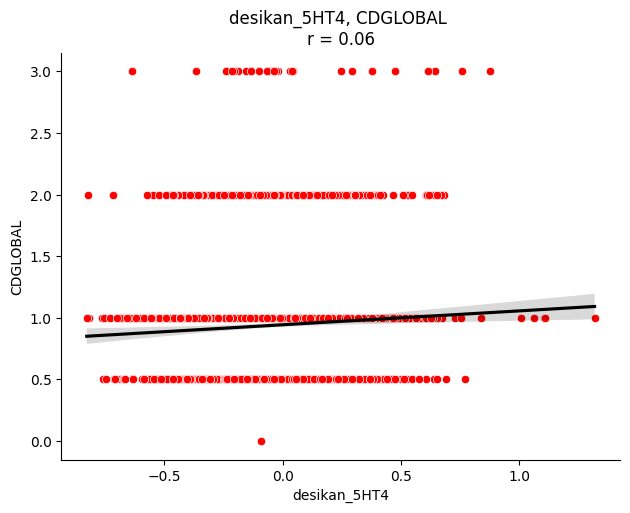

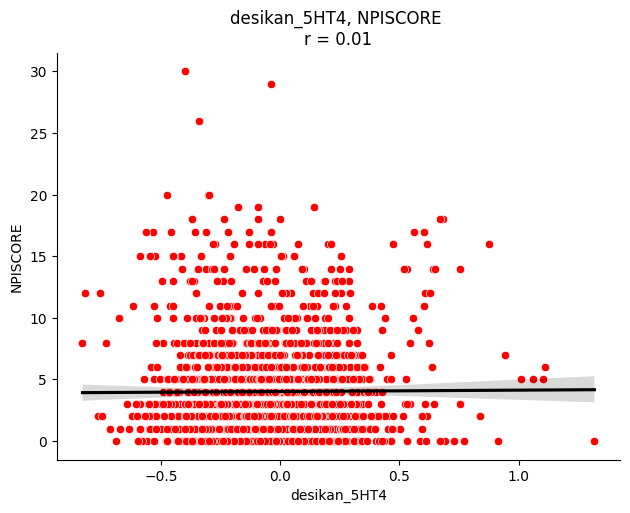

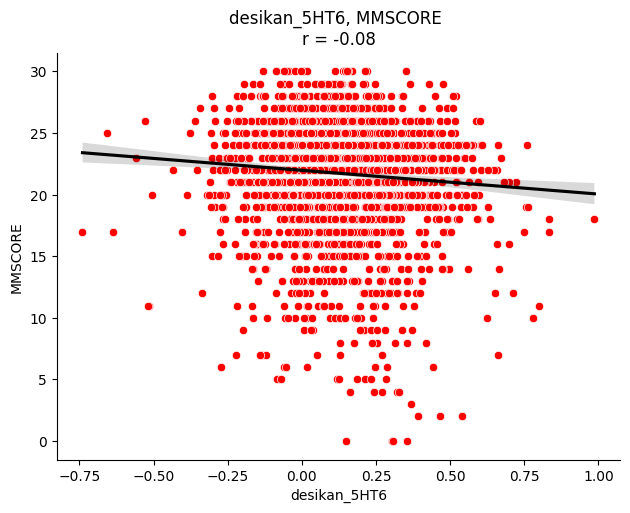

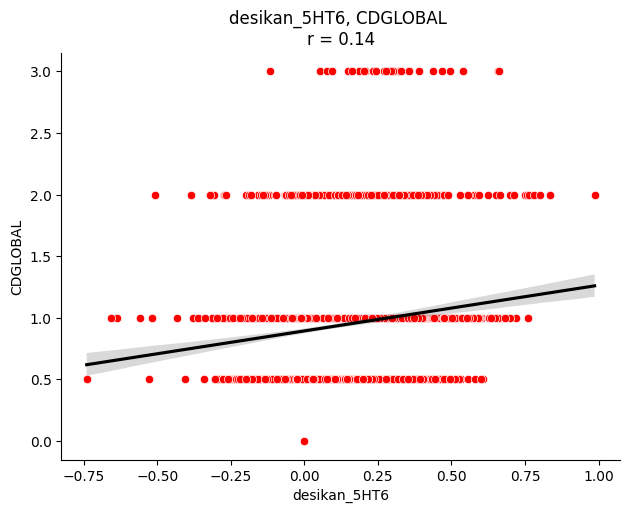

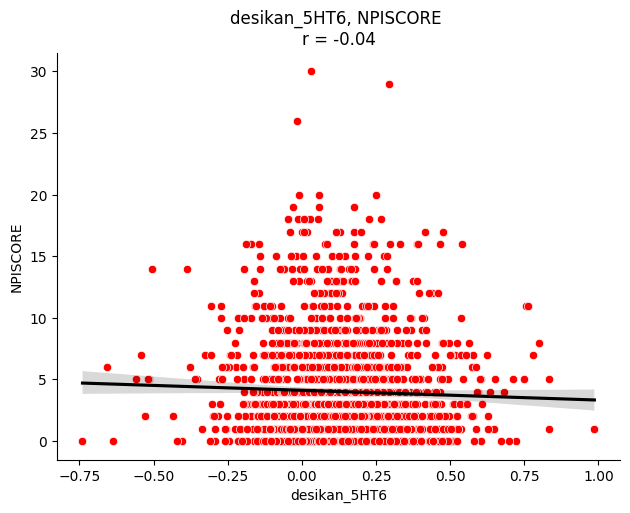

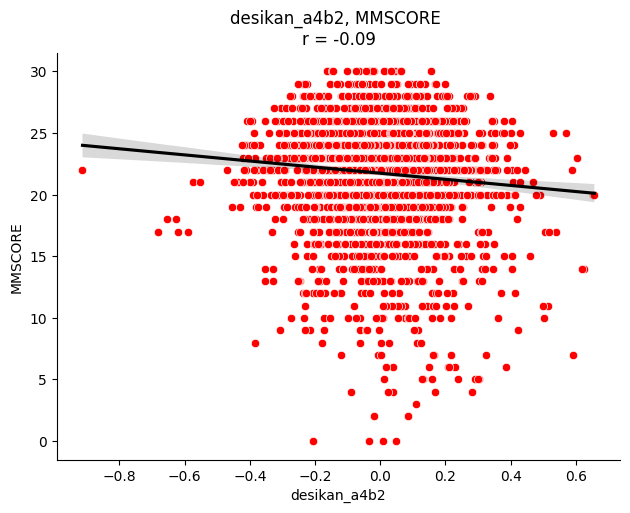

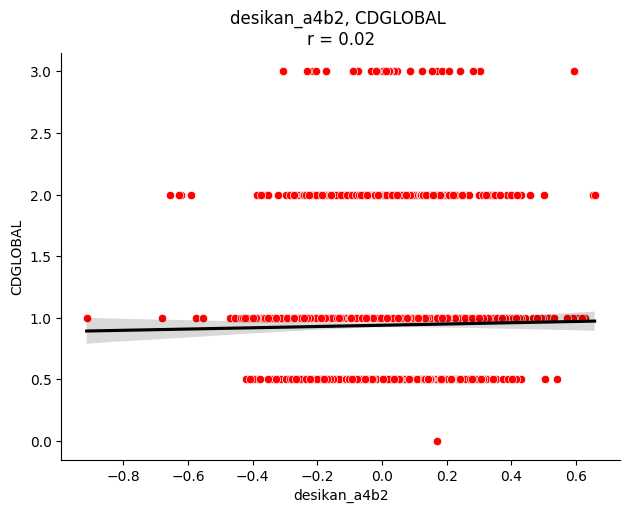

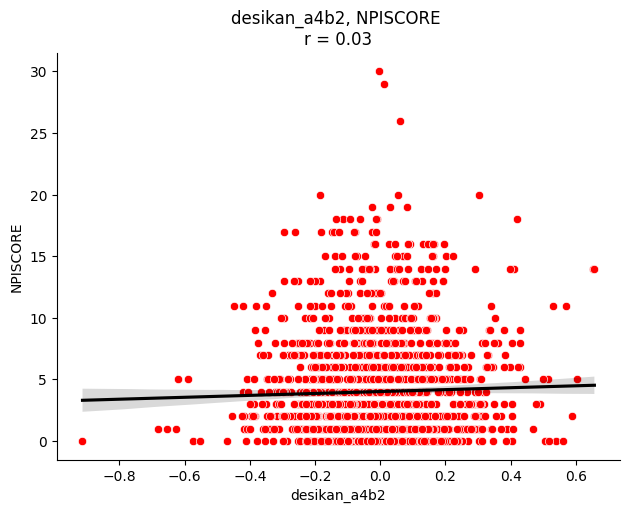

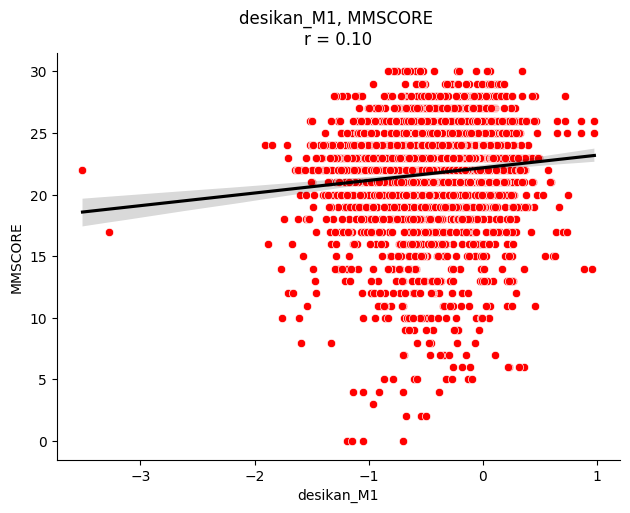

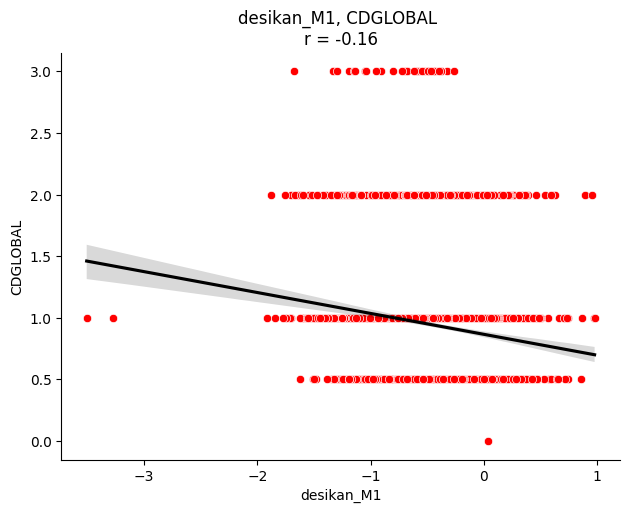

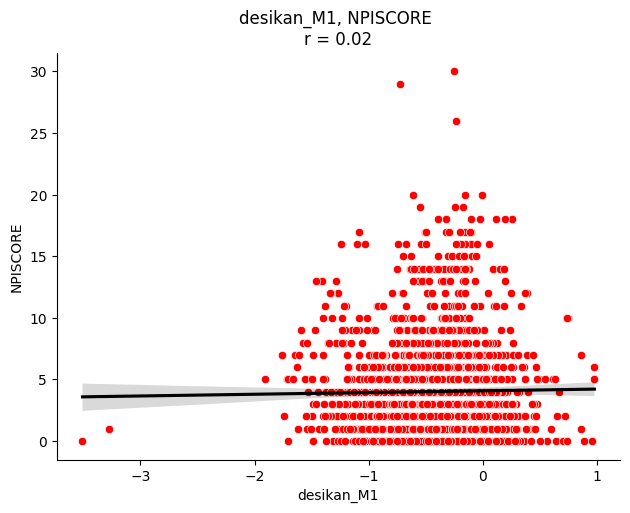

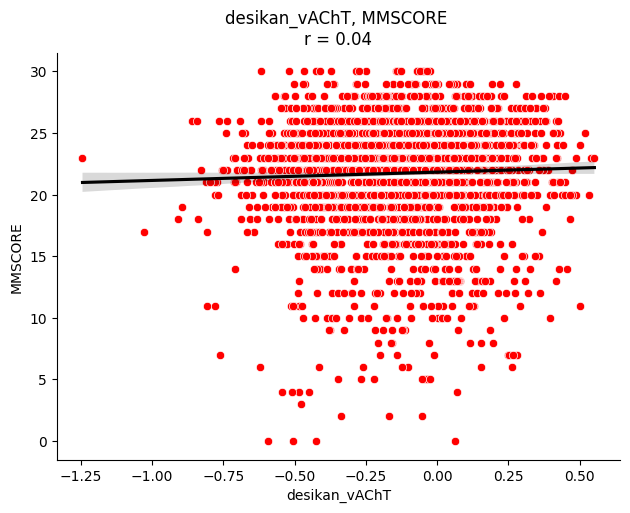

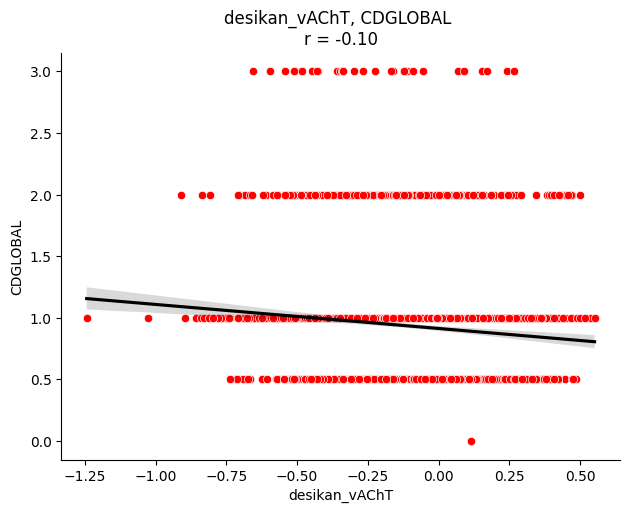

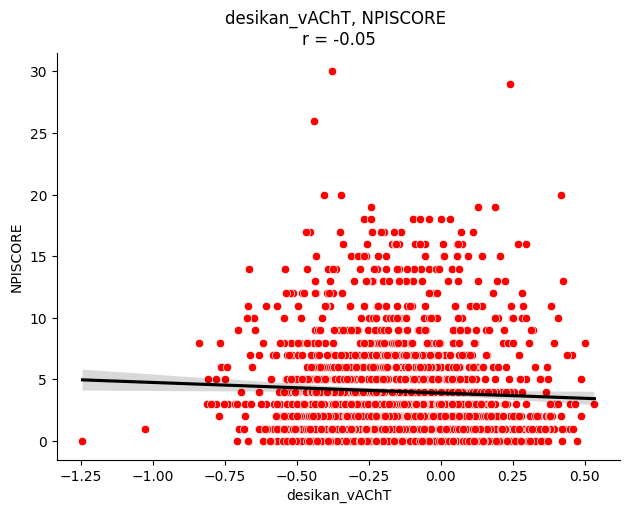

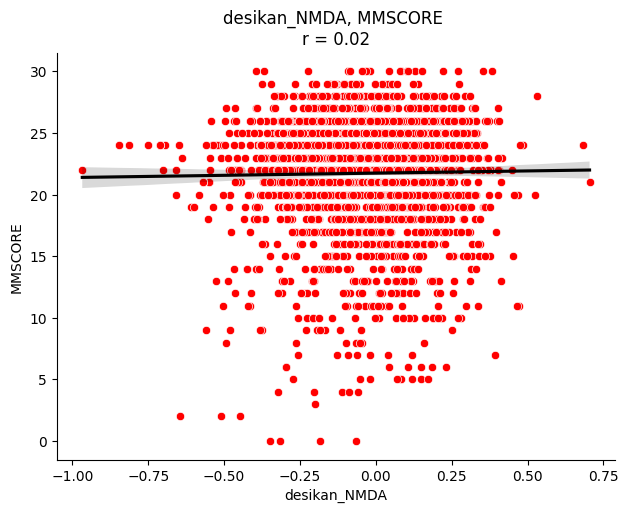

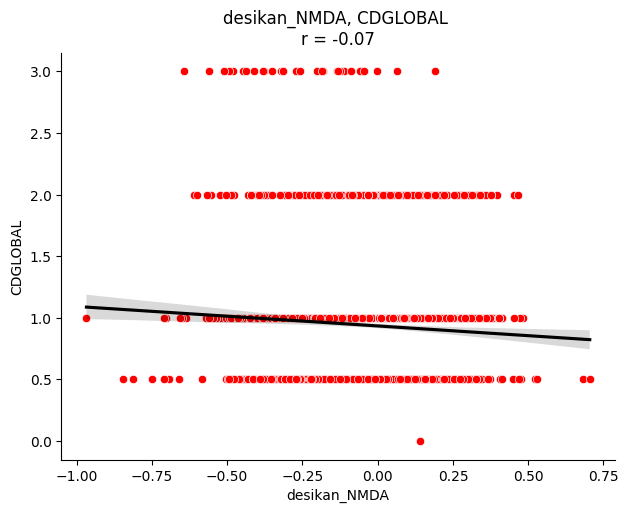

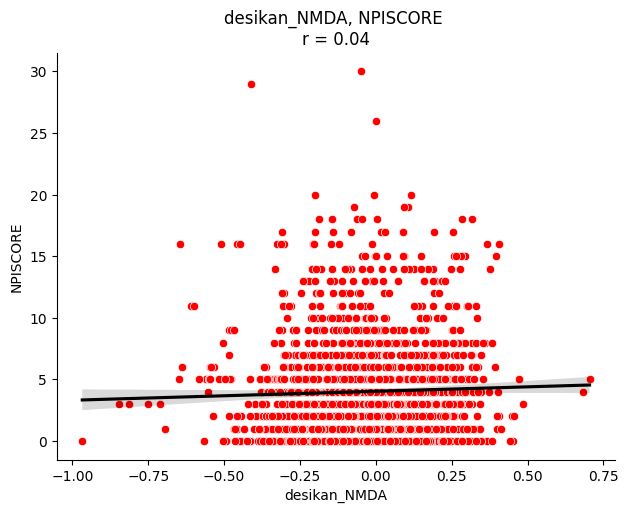

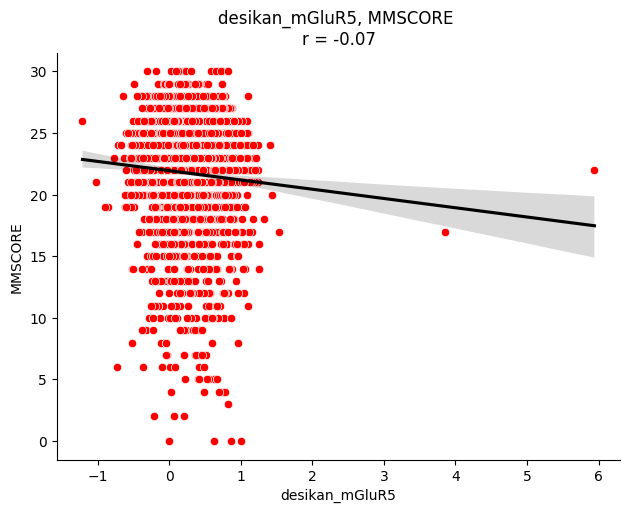

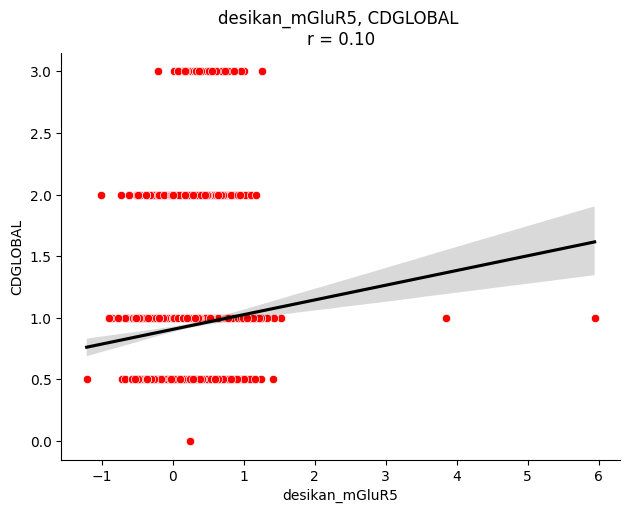

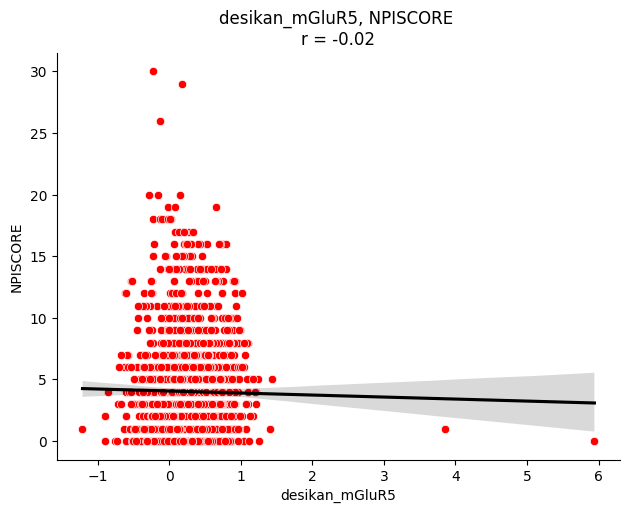

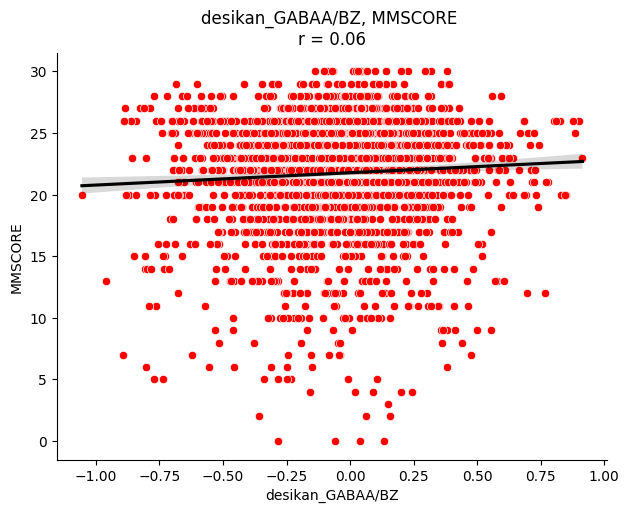

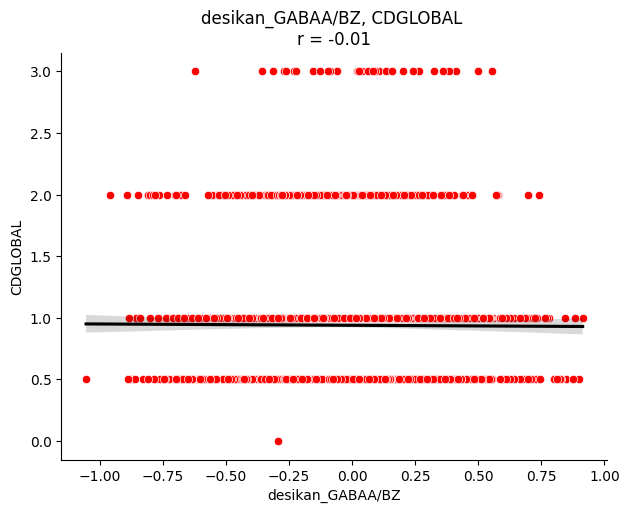

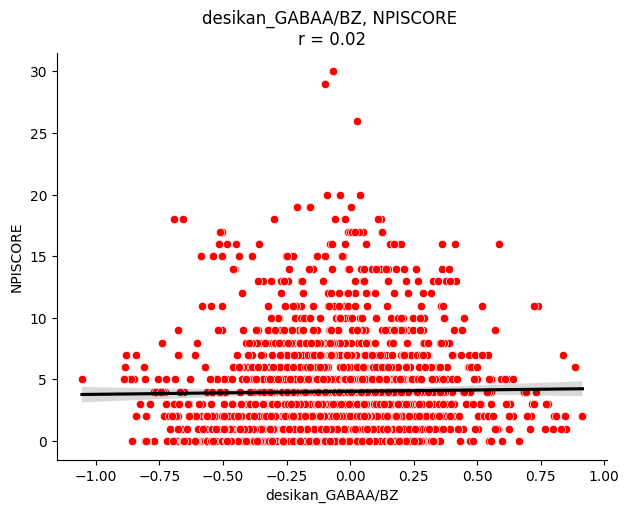

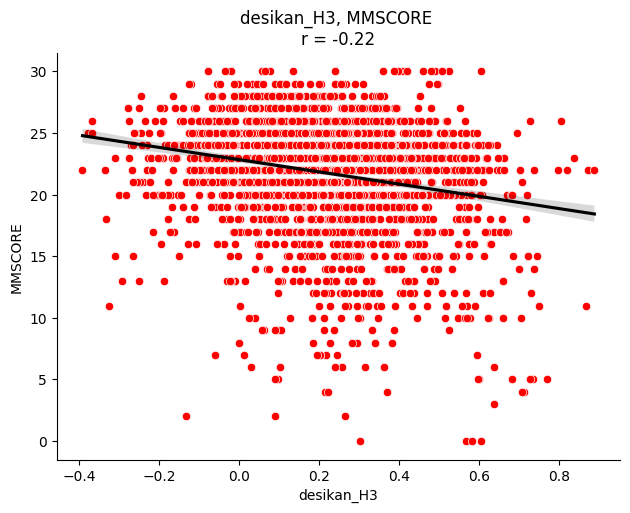

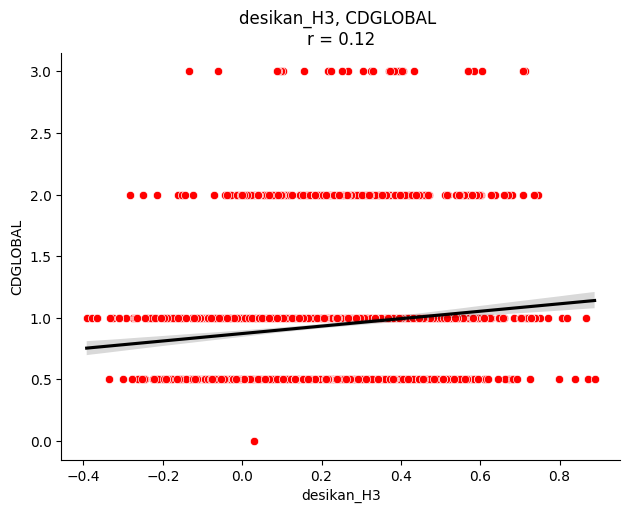

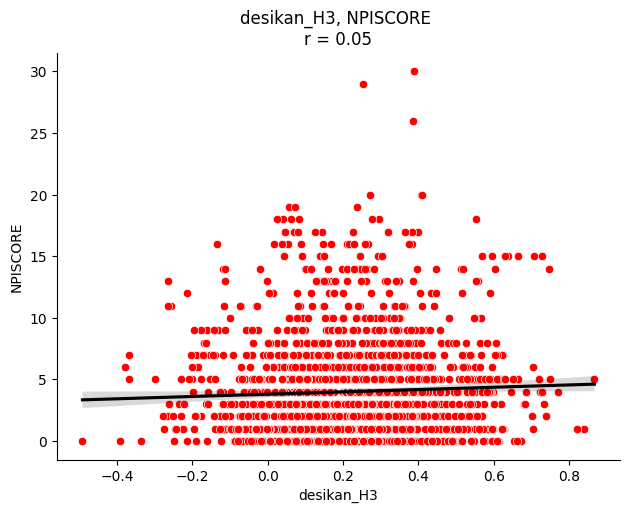

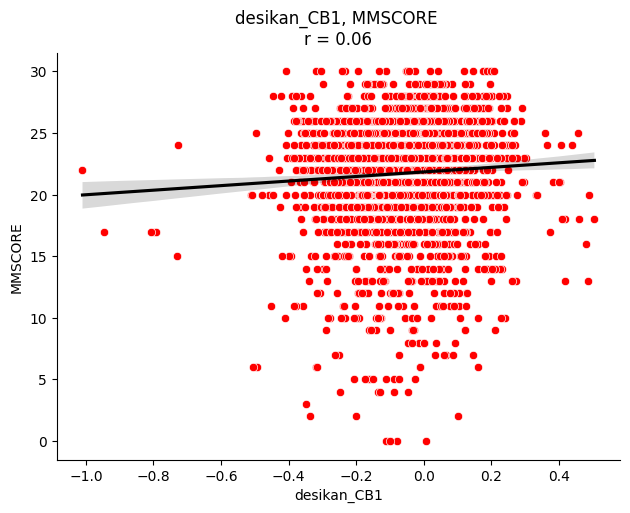

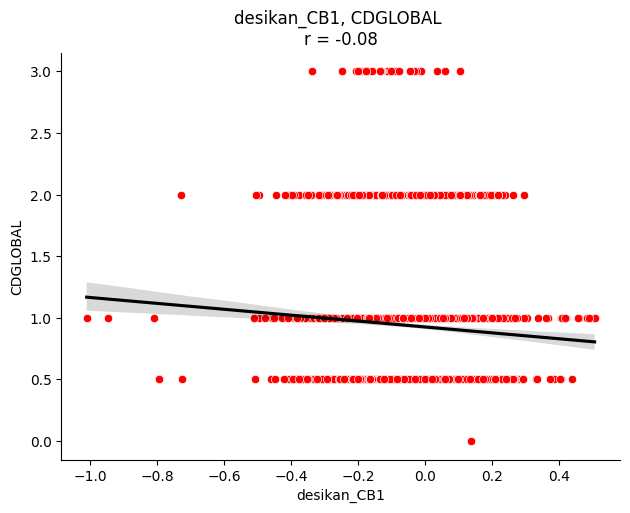

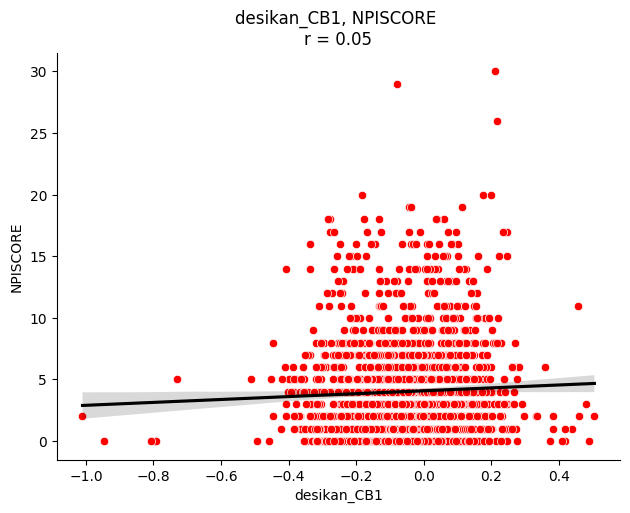

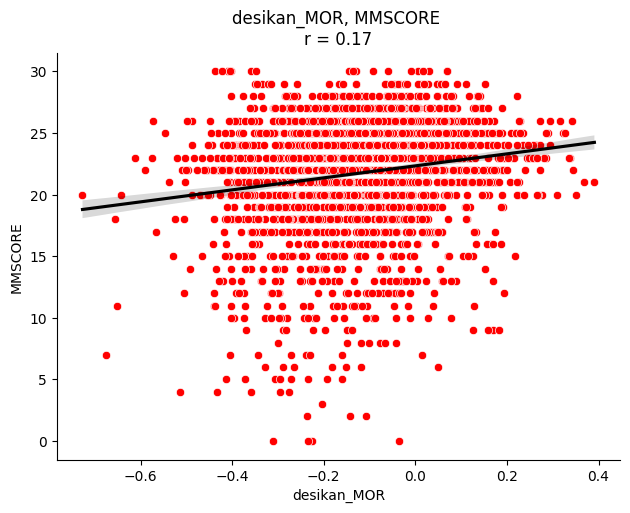

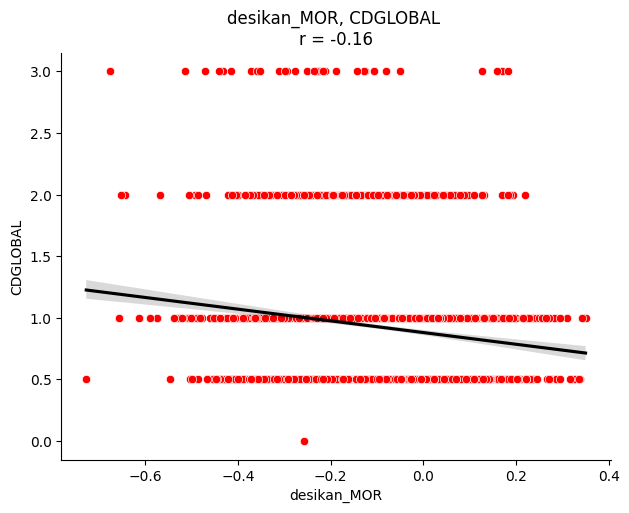

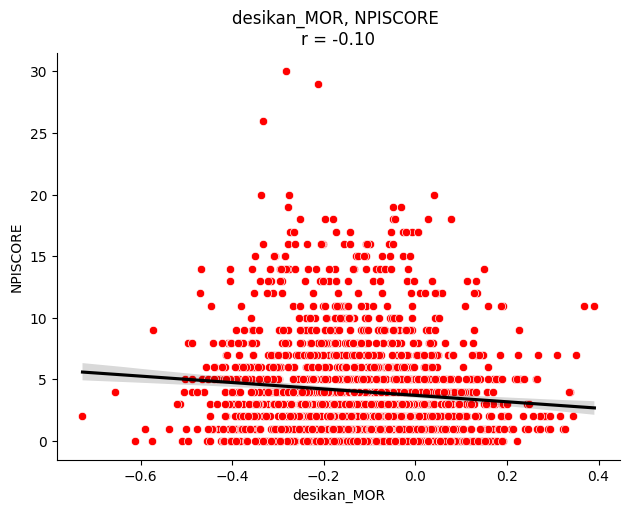

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats import multitest
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/ad_symptoms'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv',
    low_memory=False
)

coeff_cols = [
    'desikan_D1','desikan_NET','desikan_5HT1A','desikan_5HT2A','desikan_5HT4',
    'desikan_5HT6','desikan_a4b2','desikan_M1','desikan_vAChT','desikan_NMDA',
    'desikan_mGluR5','desikan_GABAA/BZ','desikan_H3','desikan_CB1','desikan_MOR'
]

symptom_cols = ['MMSCORE', 'CDGLOBAL', 'NPISCORE']

symptoms_outdir = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/ad_symptoms'
os.makedirs(symptoms_outdir, exist_ok=True)

df_subset = df[['DIAGNOSIS'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS'] == 3]

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        r, p = pearsonr(tmp[coeff], tmp[symp])
        sns.scatterplot(data = tmp, x = coeff, y = symp, color = 'r')
        sns.regplot(data = tmp, x = coeff, y = symp, ci = 95, line_kws = dict(color = 'k'), scatter = False)
        sns.despine()
        plt.tight_layout()
        plt.title(f'{coeff}, {symp} \nr = {r:.2f}')
        coeff_safe = coeff.replace('/','_')
        plt.savefig(f"{outdir}/feature_select_scatter_{coeff_safe}_{symp}.png", dpi=300)
        plt.show()


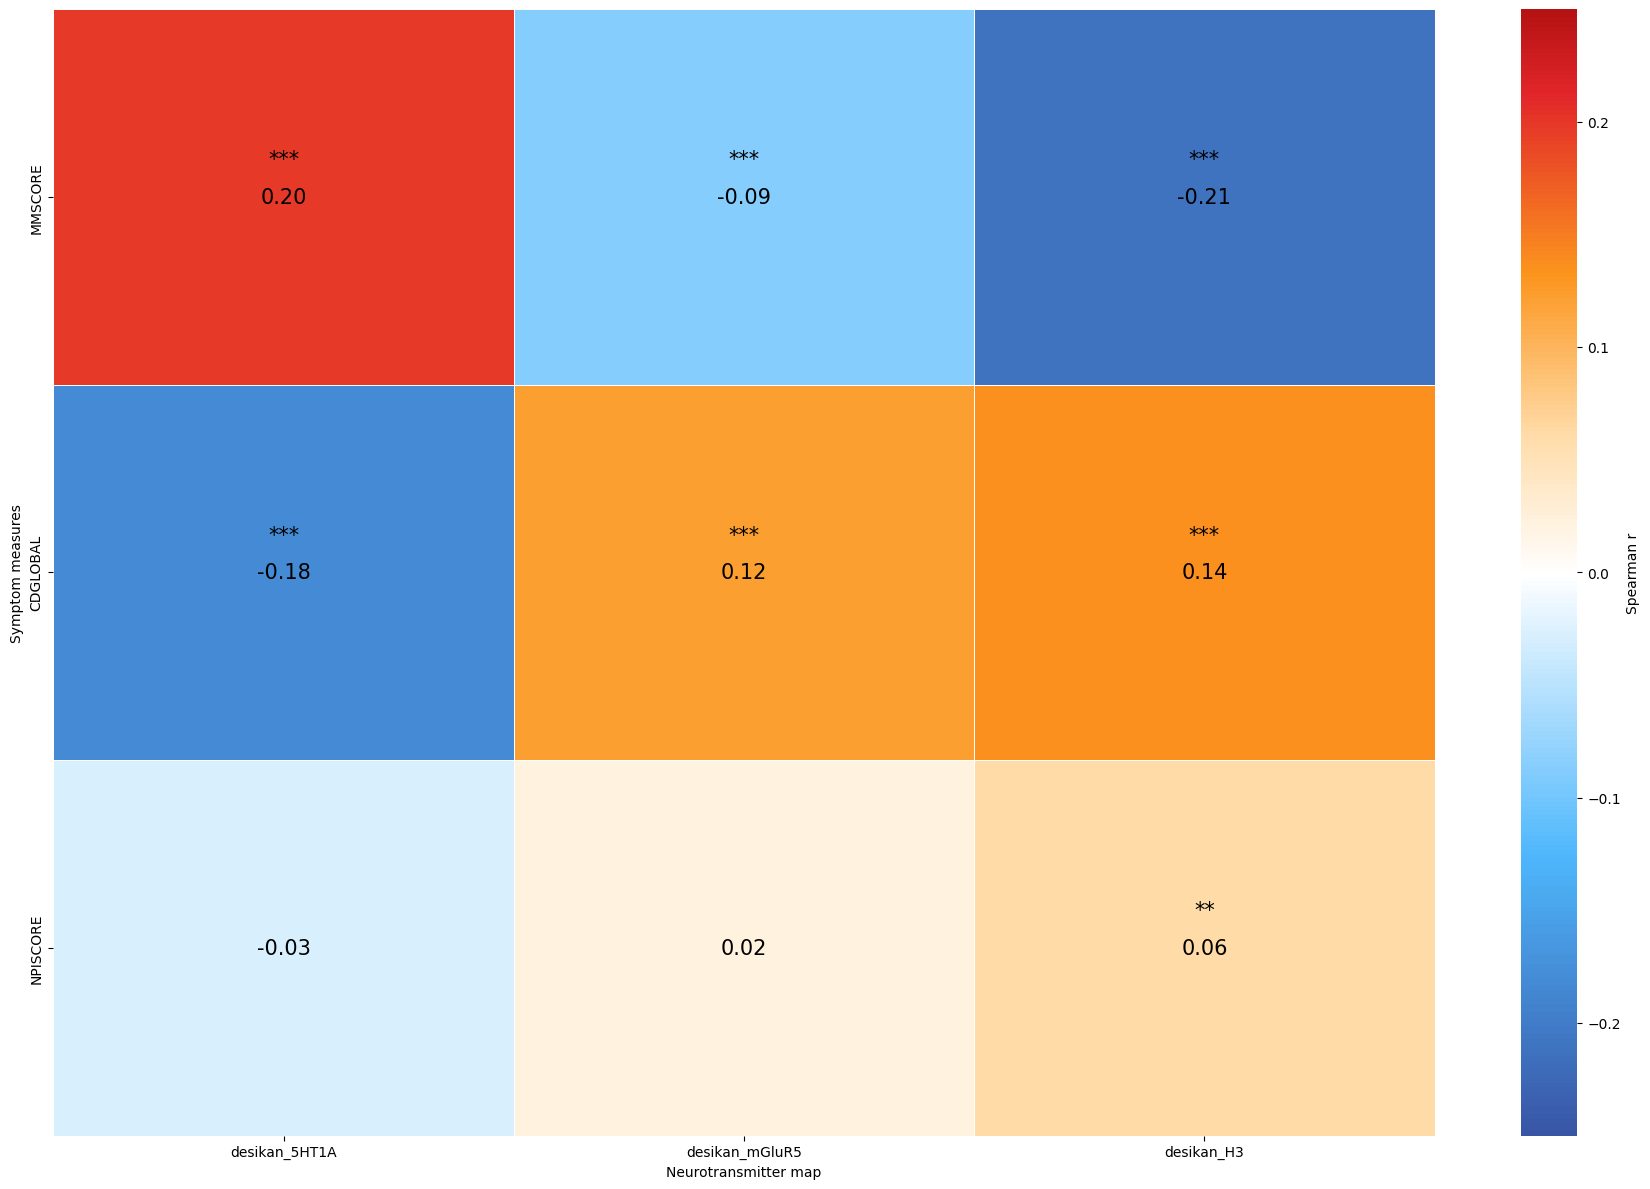


MMSCORE
Top feature: desikan_H3
Spearman r: -0.213
p-value (FDR): 1.474e-27

CDGLOBAL
Top feature: desikan_5HT1A
Spearman r: -0.182
p-value (FDR): 1.567e-20

NPISCORE
Top feature: desikan_H3
Spearman r: 0.061
p-value (FDR): 9.729e-03


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats import multitest
from matplotlib.colors import ListedColormap
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/heatmaps'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv',
    low_memory=False
)

coeff_cols = ['desikan_5HT1A', 'desikan_mGluR5','desikan_H3']

symptom_cols = ['MMSCORE', 'CDGLOBAL', 'NPISCORE']

cmap = np.genfromtxt(
    '/rds/general/project/c3nl_scott_students/live/sankeith/standards/colourmap.csv',
    delimiter=','
)
cmap_div = ListedColormap(cmap)

df_subset = df[['DIAGNOSIS'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS'] == 3]

r_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)
p_values = pd.DataFrame(index=coeff_cols, columns=symptom_cols, dtype=float)

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()

        if len(tmp) > 1:
            r, p = spearmanr(tmp[coeff], tmp[symp])
        else:
            r, p = np.nan, np.nan

        r_values.loc[coeff, symp] = r
        p_values.loc[coeff, symp] = p

r_values = r_values.transpose()
p_values = p_values.transpose()

p_flat = p_values.values.flatten()
mask = ~np.isnan(p_flat)

p_corr = np.full_like(p_flat, np.nan)
p_corr[mask] = multitest.multipletests(p_flat[mask], method='fdr_bh')[1]

p_values = pd.DataFrame(
    p_corr.reshape(p_values.shape),
    index=p_values.index,
    columns=p_values.columns
)

plt.figure(figsize=(18, 12))

ax = sns.heatmap(
    r_values,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': "Spearman r"},
    annot_kws={'color': 'black', 'fontsize': 15, 'va': 'center'},
    linewidths=0.5,
    linecolor='white'
)

n_rows, n_cols = r_values.shape

for y in range(n_rows):
    for x in range(n_cols):
        r = r_values.iloc[y, x]
        p = p_values.iloc[y, x]

        if not np.isnan(r) and not np.isnan(p):
            stars = get_significance_stars(p)

            if stars:
                ax.text(
                    x + 0.5,     # center of cell (x)
                    y + 0.4,    # slightly above rho
                    stars,
                    ha='center',
                    va='center',
                    fontsize=15,
                    color='black'
                )

plt.xlabel('Neurotransmitter map')
plt.ylabel('Symptom measures')
plt.tight_layout()

plt.savefig(f"{outdir}/top3_spearman_heatmap_overlay_stars.png", dpi=300)

plt.show()


alpha = 0.05  # significance threshold (after FDR)

for symp in r_values.index:
    r_row = r_values.loc[symp]
    p_row = p_values.loc[symp]

    summary_df = pd.DataFrame({
        'rho': r_row,
        'abs_rho': r_row.abs(),
        'pval': p_row
    })

    # keep only significant results
    summary_df = summary_df[summary_df['pval'] <= alpha]

    if summary_df.empty:
        print(f"{symp}: no significant associations after correction")
        continue

    # sort by absolute rho
    summary_df = summary_df.sort_values(by='abs_rho', ascending=False)

    top = summary_df.iloc[0]

    print(f"\n{symp}")
    print(f"Top feature: {top.name}")
    print(f"Spearman r: {top['rho']:.3f}")
    print(f"p-value (FDR): {top['pval']:.3e}")

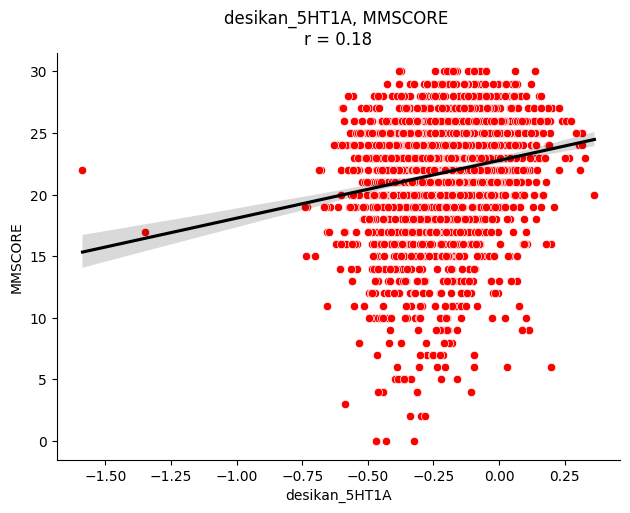

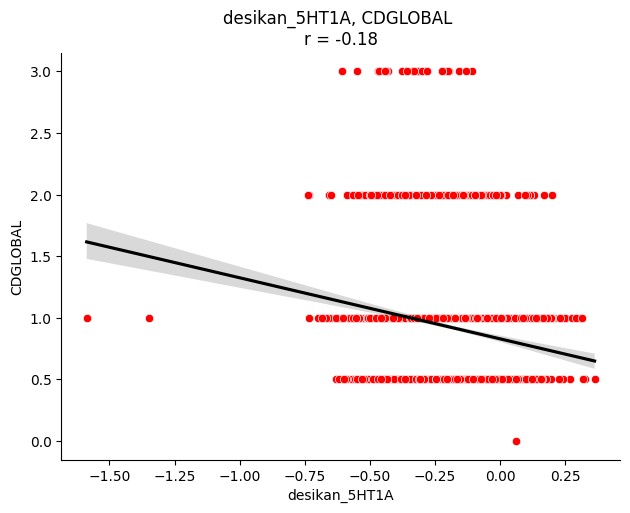

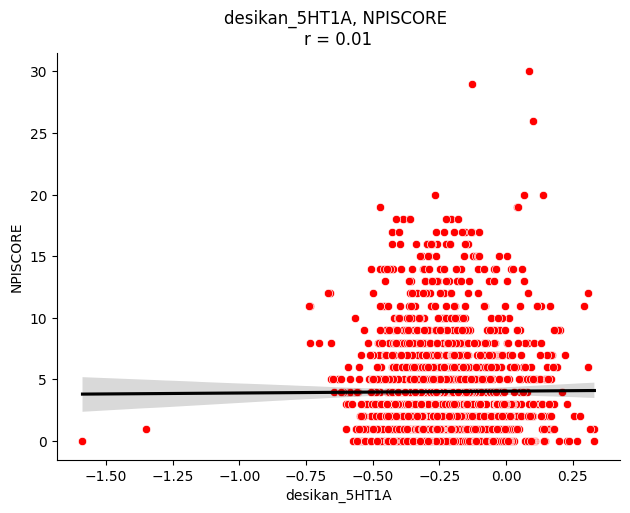

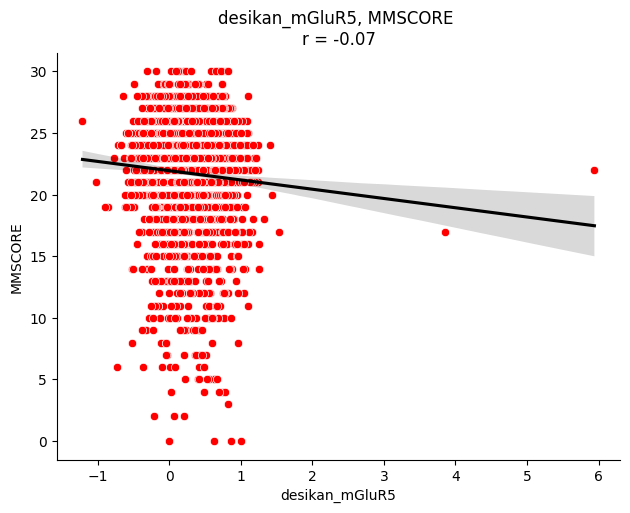

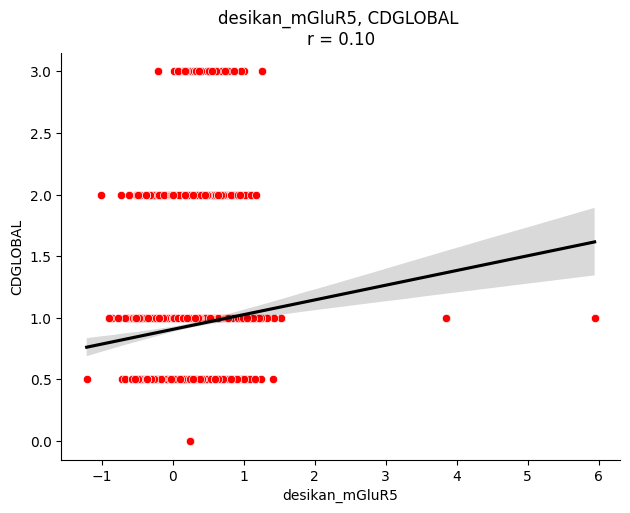

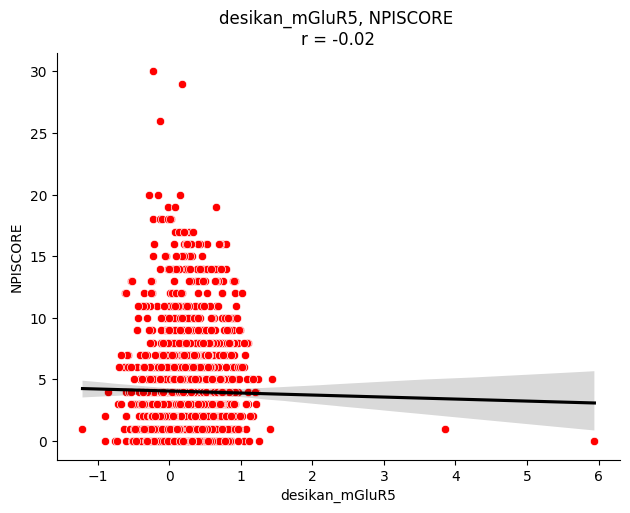

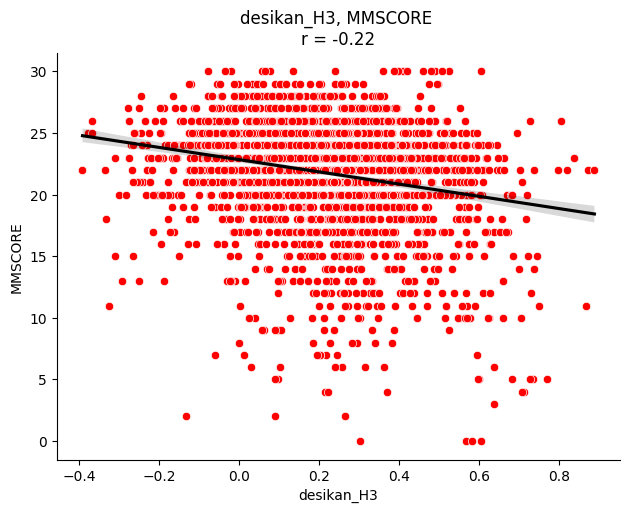

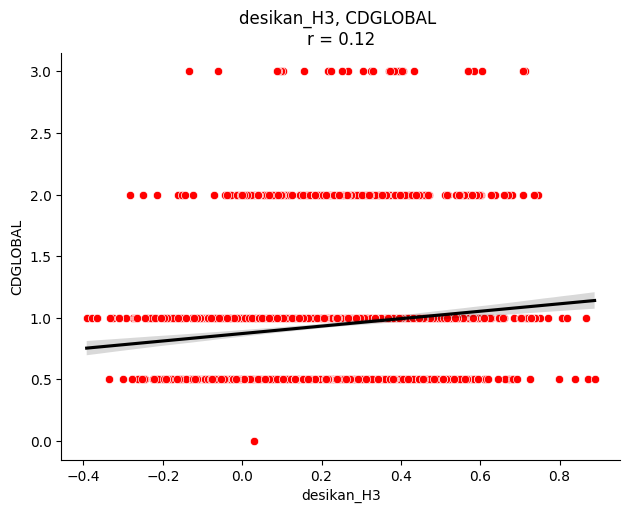

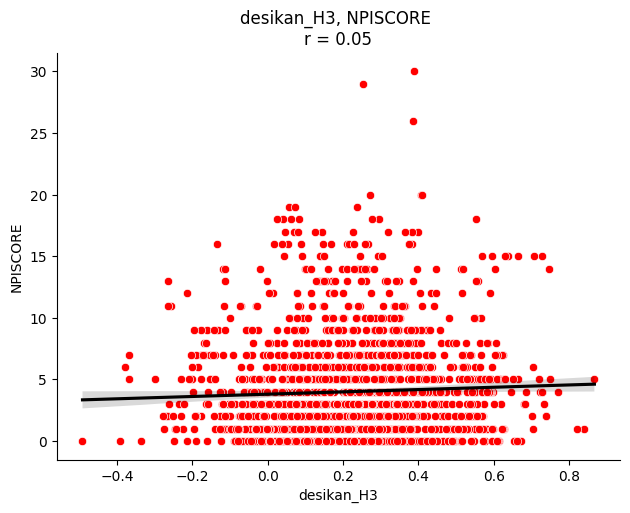

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats import multitest
from matplotlib import font_manager

font_path = "/rds/general/user/sk4724/home/arial.ttf"
font_manager.fontManager.addfont(font_path)

def get_significance_stars(p_value):
    if p_value <= 0.001: return '***'
    elif p_value <= 0.01: return '**'
    elif p_value <= 0.05: return '*'
    else: return ''

outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/ad_symptoms'
os.makedirs(outdir, exist_ok=True)

df = pd.read_csv(
    '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv',
    low_memory=False
)

coeff_cols = ['desikan_5HT1A', 'desikan_mGluR5','desikan_H3']


symptom_cols = ['MMSCORE', 'CDGLOBAL', 'NPISCORE']


symptoms_outdir = '/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_analysis/ad_symptoms'
os.makedirs(symptoms_outdir, exist_ok=True)

df_subset = df[['DIAGNOSIS'] + coeff_cols + symptom_cols]
df_subset = df_subset[df_subset['DIAGNOSIS'] == 3]

for coeff in coeff_cols:
    for symp in symptom_cols:
        tmp = df_subset[[coeff, symp]].copy()
        tmp = tmp[tmp[symp] >= 0].dropna()
        r, p = pearsonr(tmp[coeff], tmp[symp])
        sns.scatterplot(data = tmp, x = coeff, y = symp, color = 'r')
        sns.regplot(data = tmp, x = coeff, y = symp, ci = 95, line_kws = dict(color = 'k'), scatter = False)
        sns.despine()
        plt.tight_layout()
        plt.title(f'{coeff}, {symp} \nr = {r:.2f}')
        coeff_safe = coeff.replace('/','_')
        plt.savefig(f"{outdir}/top3_scatter_{coeff_safe}_{symp}.png", dpi=300)
        plt.show()


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('/rds/general/project/c3nl_scott_students/live/sankeith/scott_10k_housekeeping/sbm_w_vbm_scott10k_alliedhealth.csv', low_memory = False)
print(df['PTID'].value_counts())
print(len(df['PTID'].value_counts().tolist()))

PTID
023_S_0331    34
023_S_0031    32
023_S_0061    29
023_S_1046    29
016_S_1326    28
              ..
941_S_7051     1
941_S_7074     1
941_S_7085     1
941_S_7087     1
941_S_7106     1
Name: count, Length: 2635, dtype: int64
2635
